## Cinsiyet Sınıflandırma Projesi
---

## 1. Kütüphanelerin Kurulumu

In [19]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import correlate
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Gorsel ayarlar
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Tum kutuphaneler yuklendi.')


Tum kutuphaneler yuklendi.


## 2. Yapılandırma

In [20]:
DATASET_DIR   = "Midterm_Dataset_2026/" # Grup_01, Grup_02... klasorlerinin bulundugu ana klasor
METADATA_PATH = "MetaData.xlsx"         # Birlestirilmis metadata dosyasinin yolu

# Farkli kurulumlara uyum icin otomatik yedek klasorler
fallback_dirs = ["Midterm_Dataset_2026/", "midterm_dataset_2026/", "Dataset/"]
if not os.path.isdir(DATASET_DIR):
    for f in fallback_dirs:
        if os.path.isdir(f):
            DATASET_DIR = f
            break

if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(
        f"DATASET_DIR bulunamadi (denenenler = {DATASET_DIR} + fallback listesindekiler).\n"
        "Dogru klasorun yolunu girin ve tekrar calistirin."
    )

# Pencere parametreleri
FRAME_MS   = 25       # ms - pencere uzunlugu
HOP_MS     = 10       # ms - pencere kaymasi
SR_TARGET  = 22050    # Hedef ornekleme hizi (librosa standart)

# F0 arama araliklari (Hz)
F0_MIN = 50
F0_MAX = 500

print(f'Dataset klasoru : {DATASET_DIR}')
print(f'Metadata dosyasi: {METADATA_PATH}')

# Etiket esleme
CINSIYET_MAP = {
    'E': 'Erkek', 'M': 'Erkek',
    'K': 'Kadın', 'F': 'Kadın',
    'C': 'Çocuk'
}


Dataset klasoru : Midterm_Dataset_2026/
Metadata dosyasi: MetaData.xlsx


## 3. Veri Seti Yükleme ve Merkezi Metadata Oluşturma

In [21]:
def load_master_metadata(metadata_path, dataset_dir):
    """
    Tek birlestirilmis metadata xlsx dosyasini okur,
    her satir icin gercek dosya yolunu ekler.
    """
    df = pd.read_excel(metadata_path)

    # Sutun isimlerini temizle (bas/son bosluk)
    df.columns = df.columns.str.strip()

    # Beklenen sutunlari kontrol et
    beklenen = ['File name', 'Subject_ID', 'Gender', 'Age', 'Feeling',
                'Sentence_No', 'Recording_Device', 'ENVIRONMENT', 'noise level']
    eksik = [s for s in beklenen if s not in df.columns]
    if eksik:
        print(f'UYARI: Metadata dosyasinda su sutunlar bulunamadi: {eksik}')

    # Gender'i normalize et: M->E, F->K, diger degerler oldugu gibi
    df['Gender'] = df['Gender'].astype(str).str.strip().str.upper().map({
        'E': 'E', 'M': 'E',
        'K': 'K', 'F': 'K',
        'C': 'C'
    }).fillna(df['Gender'].astype(str).str.strip().str.upper())

    # Tanimsiz Gender degerlerini logla
    tanimsiz = df[~df['Gender'].isin(['E', 'K', 'C'])]['Gender'].unique()
    if len(tanimsiz) > 0:
        print(f'UYARI: Tanimsiz Gender degerleri: {tanimsiz}')

    # Gosterim icin Turkce etiket
    df['Cinsiyet_Tam'] = df['Gender'].map(CINSIYET_MAP).fillna('Bilinmiyor')

    # Dosya yolunu bul
    def bul_dosya_yolu(dosya_adi):
        # NaN veya bos deger kontrolu
        if pd.isna(dosya_adi) or str(dosya_adi).strip() == '':
            return None

        dosya_adi = str(dosya_adi).strip()

        # Uzanti yoksa .wav ekle
        if not dosya_adi.endswith('.wav'):
            dosya_adi = dosya_adi + '.wav'

        try:
            grup_no   = dosya_adi.split('_')[0]
            grup_sayi = grup_no.replace('G', '').zfill(2)
            klasor    = os.path.join(dataset_dir, f'Grup_{grup_sayi}', dosya_adi)
            if os.path.exists(klasor):
                return klasor
        except:
            pass

        # Fallback: tum klasorlerde ara
        matches = glob.glob(os.path.join(dataset_dir, '**', dosya_adi), recursive=True)
        return matches[0] if matches else None

    df['Dosya_Yolu'] = df['File name'].apply(bul_dosya_yolu)

    bulunan = df['Dosya_Yolu'].notna().sum()
    toplam  = len(df)
    print(f'Toplam satir    : {toplam}')
    print(f'Dosya bulundu   : {bulunan}')
    print(f'Dosya bulunamadi: {toplam - bulunan}')

    # Bulunamayan dosyalari listele
    kayip = df[df['Dosya_Yolu'].isna()]['File name'].tolist()
    if kayip:
        if kayip:
            print('Bulunamayan dosyalar:')
            for d in kayip:
                print(f'  - {d}')

    print()
    print('Gender dagilimi:')
    print(df['Cinsiyet_Tam'].value_counts().to_string())

    return df

master_df = load_master_metadata(METADATA_PATH, DATASET_DIR)

Toplam satir    : 703
Dosya bulundu   : 594
Dosya bulunamadi: 109
Bulunamayan dosyalar:
  - G04_D04_F_21_Furious_C3.wav
  - G04_D04_F_21_Neutral_C1.wav
  - G04_D04_F_21_Shocked_C5.wav
  - G05_D01_C_9_Happy_C2.wav
  - G05_D01_C_9_Happy_C2.wav
  - G06_D01_F_20_Shocked_C5.wav
  - G07_D01_M_22_Shocked_C5.wav
  - G07_D02_M_50_Furious_C3.wav
  - G07_D03_F_40_Sad_C4.wav
  - G07_D04_F_20_Furious_C4.wav
  - G07_D05_C_15_Furious_C3.wav
  - G07_D05_C_15_Shocked_C5.wav
  - G07_D06_C_15_Sad_C4.wav
  - G09_D03_E_21_Furious_C3.wav
  - G09_D04_E_42_Sad_C4.wav
  - G09_D06_C_12_Shocked_C5.wav
  - G12_D06_C_9_Happy_C2.wav
  - G15_D01_E_21_Neutral_C1.wav
  - G15_D01_E_21_Furious_C3.wav
  - G15_D01_E_21_Sad_C4.wav
  - G15_D02_C_16_Neutral_C1.wav
  - G15_D02_C_16_Furious_C3.wav
  - G15_D02_C_16_Shocked_C5.wav
  - G15_D03_K_20_Furious_C3.wav
  - G15_D03_K_20_Shocked_C5.wav
  - G15_D03_K_20_Sad_C4.wav
  - G15_D04_C_10_Neutral_C1.wav
  - G15_D04_C_10_Furious_C3.wav
  - G15_D04_C_10_Shocked_C5.wav
  - G15_D05_E

## 4. Sinyal İşleme Fonksiyonları

### 4.1 Kısa Süreli Enerji (STE) ve Sıfır Geçiş Oranı (ZCR)

In [22]:
def hesapla_ste_zcr(y, sr, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """
    Kısa Süreli Enerji (STE) ve Sıfır Geçiş Oranı (ZCR) hesaplar.
    
    Parametreler:
        y        : ses sinyali
        sr       : örnekleme hızı
        frame_ms : pencere uzunluğu (ms)
        hop_ms   : pencere kayması (ms)
    
    Döndürür:
        ste  : her pencere için normalize edilmiş enerji
        zcr  : her pencere için sıfır geçiş oranı
    """
    frame_len = int(sr * frame_ms / 1000)
    hop_len   = int(sr * hop_ms  / 1000)
    
    # Kısa Süreli Enerji
    ste = np.array([
        np.sum(y[i:i+frame_len] ** 2)
        for i in range(0, len(y) - frame_len, hop_len)
    ])
    ste = ste / (frame_len)  # normalize
    
    # Sıfır Geçiş Oranı (librosa)
    zcr = librosa.feature.zero_crossing_rate(
        y, frame_length=frame_len, hop_length=hop_len
    )[0]
    
    # Eşit uzunluğa kırp
    min_len = min(len(ste), len(zcr))
    return ste[:min_len], zcr[:min_len]


def tespit_voiced_bolge(ste, zcr, ste_oran=0.15, zcr_esik=0.15):
    """
    STE ve ZCR kullanarak Voiced (sesli) pencereleri tespit eder.
    
    Kural:
        - STE > (max STE'nin %15'i)  → yeterli enerji var
        - ZCR < zcr_esik             → sesli bölge (ünsüzler ZCR'si yüksek)
    """
    ste_esik = ste_oran * np.max(ste)
    voiced_mask = (ste > ste_esik) & (zcr < zcr_esik)
    return voiced_mask

print('STE ve ZCR fonksiyonlari tanimlandi.')

STE ve ZCR fonksiyonlari tanimlandi.


### 4.2 Otokorelasyon ile F0 Hesaplama

In [23]:
def otokorelasyon_f0_hesapla(pencere, sr, f0_min=F0_MIN, f0_max=F0_MAX):
    """
    Tek bir ses penceresi için otokorelasyon yöntemiyle F0 hesaplar.
    
    R(τ) = Σ x[n] · x[n - τ]
    
    Parametreler:
        pencere  : ses çerçevesi (numpy array)
        sr       : örnekleme hızı
        f0_min   : aranacak minimum F0 (Hz)
        f0_max   : aranacak maksimum F0 (Hz)
    
    Döndürür:
        f0 değeri (Hz) veya None (periyodik yapı bulunamazsa)
    """
    N = len(pencere) 
    # pencere_uzunlugu
    
    # Lag (gecikme) sınırları
    lag_min = int(sr / f0_max)  # yüksek frekansta küçük periyot
    lag_max = int(sr / f0_min)  # düşük frekansta büyük periyot
    
    if lag_max >= N:
        lag_max = N - 1
    if lag_min >= lag_max:
        return None
    
    # Tam otokorelasyon (scipy)
    otokor = correlate(pencere, pencere, mode='full')
    otokor = otokor[N-1:]           # sadece pozitif lag'ler
    otokor = otokor / (otokor[0] + 1e-10)  # normalize (r[0] = maksimum)
    
    # Arama aralığında maksimum tepe noktası
    arama = otokor[lag_min:lag_max]
    if len(arama) == 0:
        return None
    
    tepe_idx = np.argmax(arama) + lag_min
    
    # Minimum güvenilirlik eşiği
    if otokor[tepe_idx] < 0.3:
        return None
    
    f0 = sr / tepe_idx
    return f0


def hesapla_ortalama_f0(y, sr, frame_ms=FRAME_MS, hop_ms=HOP_MS):
    """
    Ses dosyası için Voiced bölgelerden ortalama F0 hesaplar.
    
    Döndürür:
        ortalama_f0 (Hz), f0_listesi, voiced_mask, ste, zcr
    """
    frame_len = int(sr * frame_ms / 1000)
    hop_len   = int(sr * hop_ms  / 1000)
    
    ste, zcr = hesapla_ste_zcr(y, sr, frame_ms, hop_ms)
    voiced_mask = tespit_voiced_bolge(ste, zcr)
    
    f0_listesi = []
    pencere_idx = 0
    
    for i in range(0, len(y) - frame_len, hop_len):
        if pencere_idx < len(voiced_mask) and voiced_mask[pencere_idx]:
            pencere = y[i:i+frame_len]
            # Pencereleme (Hanning)
            pencere = pencere * np.hanning(len(pencere))
            f0 = otokorelasyon_f0_hesapla(pencere, sr)
            if f0 is not None:
                f0_listesi.append(f0)
        pencere_idx += 1
    
    ortalama_f0 = np.mean(f0_listesi) if f0_listesi else 0.0
    return ortalama_f0, f0_listesi, voiced_mask, ste, zcr

print('Otokorelasyon F0 fonksiyonlari tanimlandi.')

Otokorelasyon F0 fonksiyonlari tanimlandi.


### 4.3 FFT ile F0 karşılaştırma

In [24]:
def fft_f0_hesapla(pencere, sr, f0_min=F0_MIN, f0_max=F0_MAX):
    """
    FFT büyüklük spektrumunda ilk baskın harmonikten F0 tahmin eder.
    Karşılaştırma amacıyla kullanılır — ana yöntem otokorelasyondur.
    """
    N = len(pencere)
    pencere_hann = pencere * np.hanning(N)
    
    spectrum = np.abs(np.fft.rfft(pencere_hann, n=N*4))  # zero-padding
    freqs    = np.fft.rfftfreq(N*4, d=1/sr)
    
    # F0 aralığını maskele
    mask = (freqs >= f0_min) & (freqs <= f0_max)
    if not np.any(mask):
        return None
    
    idx = np.argmax(spectrum[mask])
    f0  = freqs[mask][idx]
    return f0

print('FFT ile F0 karsilastirma fonksiyonu tanimlandi.')

FFT ile F0 karsilastirma fonksiyonu tanimlandi.


## 5. Otokorelasyon vs FFT Görsel Karşılaştırması Demo

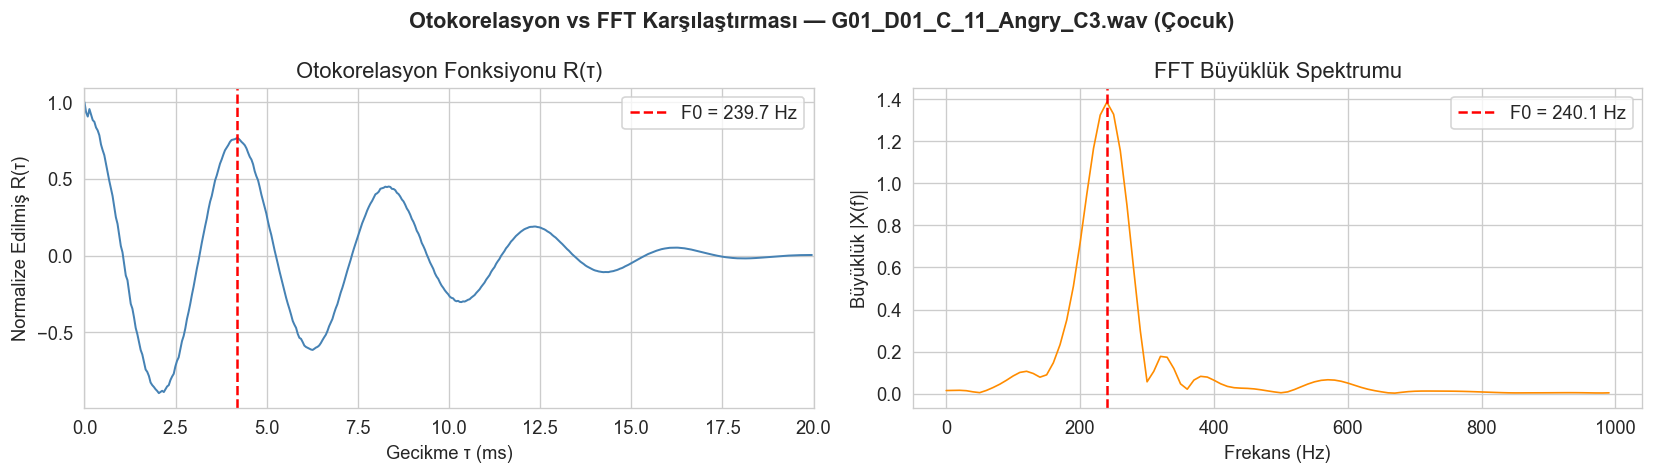


Otokorelasyon → F0 = 239.7 Hz
FFT            → F0 = 240.1 Hz

İki yöntem arası fark: 0.4 Hz (0.2%)
Yöntemler tutarlı.


In [25]:
def goster_otokor_vs_fft(dosya_yolu, etiket=''):
    """
    Seçilen bir ses dosyası için otokorelasyon ve FFT spektrumunu
    yan yana çizer ve her iki yöntemden bulunan F0'ı raporlar.
    """
    y, sr = librosa.load(dosya_yolu, sr=SR_TARGET, mono=True)
    
    # Orta 1 saniyelik voiced pencere al
    frame_len = int(sr * FRAME_MS / 1000)
    orta = len(y) // 2
    pencere = y[orta:orta+frame_len] * np.hanning(frame_len)
    
    # Otokorelasyon
    N = len(pencere)
    otokor     = correlate(pencere, pencere, mode='full')
    otokor     = otokor[N-1:]
    otokor     = otokor / (otokor[0] + 1e-10)
    lags = np.arange(len(otokor)) / sr * 1000  # ms cinsinden
    
    f0_oto = otokorelasyon_f0_hesapla(pencere, sr)
    f0_fft = fft_f0_hesapla(pencere, sr)
    
    # FFT spektrumu
    spectrum = np.abs(np.fft.rfft(pencere, n=N*4))
    freqs    = np.fft.rfftfreq(N*4, d=1/sr)
    
    # Çizim
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Otokorelasyon vs FFT Karşılaştırması — {etiket}', fontsize=13, fontweight='bold')
    
    # Sol: Otokorelasyon
    ax = axes[0]
    ax.plot(lags[:int(sr*0.02)], otokor[:int(sr*0.02)], color='steelblue', linewidth=1.2)
    if f0_oto:
        lag_f0 = sr / f0_oto / sr * 1000
        ax.axvline(lag_f0, color='red', linestyle='--', label=f'F0 = {f0_oto:.1f} Hz')
        ax.legend()
    ax.set_xlabel('Gecikme τ (ms)')
    ax.set_ylabel('Normalize Edilmiş R(τ)')
    ax.set_title('Otokorelasyon Fonksiyonu R(τ)')
    ax.set_xlim(0, 20)
    
    # Sağ: FFT Spektrumu
    ax = axes[1]
    mask = freqs <= 1000
    ax.plot(freqs[mask], spectrum[mask], color='darkorange', linewidth=1.0)
    if f0_fft:
        ax.axvline(f0_fft, color='red', linestyle='--', label=f'F0 = {f0_fft:.1f} Hz')
        ax.legend()
    ax.set_xlabel('Frekans (Hz)')
    ax.set_ylabel('Büyüklük |X(f)|')
    ax.set_title('FFT Büyüklük Spektrumu')
    
    plt.tight_layout()
    plt.savefig('outputs/otokor_vs_fft.png', bbox_inches='tight')
    plt.show()
    
    print(f'\nOtokorelasyon → F0 = {f0_oto:.1f} Hz' if f0_oto else '\nOtokorelasyon → F0 bulunamadı')
    print(f'FFT            → F0 = {f0_fft:.1f} Hz' if f0_fft else 'FFT → F0 bulunamadı')
    if f0_oto and f0_fft:
        fark = abs(f0_oto - f0_fft)
        print(f'\nİki yöntem arası fark: {fark:.1f} Hz ({fark/f0_fft*100:.1f}%)')
        print('Yöntemler tutarlı.' if fark < 20 else 'Yöntemler arasında belirgin fark var.')


# İlk mevcut dosyayı örnek olarak kullan
mevcut_df = master_df[master_df['Dosya_Yolu'].notna()]
if mevcut_df.empty:
    raise ValueError(
        "master_df içinde Dosya_Yolu dolu satır bulunamadı.\n"
        "DATASET_DIR ve METADATA_PATH ayarlarını kontrol edin."
    )

ornek_satir = mevcut_df.iloc[0]
if pd.isna(ornek_satir['Dosya_Yolu']) or not os.path.exists(ornek_satir['Dosya_Yolu']):
    raise FileNotFoundError(f"Örnek dosya bulunamadı: {ornek_satir['Dosya_Yolu']}")

goster_otokor_vs_fft(
    ornek_satir['Dosya_Yolu'],
    etiket=f"{ornek_satir.get('File name', 'Bilinmiyor')} ({ornek_satir.get('Cinsiyet_Tam', 'Bilinmiyor')})"
)

## 6. Tüm Veri Seti Üzerinde Öznitelik Çıkarımı

In [26]:
def ozellik_cikar(dosya_yolu, sr_target=SR_TARGET):
    """
    Bir ses dosyasindan F0, ZCR ve Enerji ozniteliklerini cikarir.

    Dondurur: dict {ortalama_f0, std_f0, ort_zcr, ort_enerji, voiced_oran, hata}
    """
    try:
        y, sr = librosa.load(dosya_yolu, sr=sr_target, mono=True)

        # Normalize et
        if np.max(np.abs(y)) > 0:
            y = y / np.max(np.abs(y))

        ort_f0, f0_list, voiced_mask, ste, zcr = hesapla_ortalama_f0(y, sr)

        voiced_oran = voiced_mask.mean() if len(voiced_mask) > 0 else 0
        ort_zcr     = float(np.mean(zcr[voiced_mask])) if voiced_mask.any() else float(np.mean(zcr))
        ort_enerji  = float(np.mean(ste[voiced_mask])) if voiced_mask.any() else float(np.mean(ste))
        std_f0      = float(np.std(f0_list)) if f0_list else 0.0

        return {
            'ortalama_f0' : round(ort_f0, 2),
            'std_f0'      : round(std_f0, 2),
            'ort_zcr'     : round(ort_zcr, 4),
            'ort_enerji'  : round(ort_enerji, 6),
            'voiced_oran' : round(voiced_oran, 3),
            'hata'        : None
        }
    except Exception as e:
        return {'ortalama_f0': None, 'std_f0': None, 'ort_zcr': None,
                'ort_enerji': None, 'voiced_oran': None, 'hata': str(e)}


# Tum dosyalar uzerinde calistir
print('Oznitelik cikarimi basladi...')
print('(Bu islem birkac dakika surebilir)\n')

sonuclar   = []
df_mevcut  = master_df[master_df['Dosya_Yolu'].notna()].copy()

# Tasimak istedigimiz metadata sutunlari
meta_sutunlar = ['Subject_ID', 'Gender', 'Cinsiyet_Tam', 'Age', 'Feeling',
                 'Sentence_No', 'Recording_Device', 'ENVIRONMENT', 'noise level']

for idx, (_, satir) in enumerate(df_mevcut.iterrows()):
    ozellikler = ozellik_cikar(satir['Dosya_Yolu'])
    ozellikler['File name'] = satir['File name']
    for sutun in meta_sutunlar:
        ozellikler[sutun] = satir.get(sutun, None)
    sonuclar.append(ozellikler)

    # Ilerleme
    if (idx + 1) % 20 == 0 or (idx + 1) == len(df_mevcut):
        print(f'  {idx+1}/{len(df_mevcut)} dosya islendi...')

ozellik_df = pd.DataFrame(sonuclar)

hatalar = ozellik_df['hata'].notna().sum()
print(f'\nTamamlandi! {len(ozellik_df) - hatalar} dosya basarili, {hatalar} hata.')
if hatalar > 0:
    print(ozellik_df[ozellik_df['hata'].notna()][['File name', 'hata']].head().to_string())
else:
    print('Tum dosyalar hatasiz.')


Oznitelik cikarimi basladi...
(Bu islem birkac dakika surebilir)

  20/594 dosya islendi...
  40/594 dosya islendi...
  60/594 dosya islendi...
  80/594 dosya islendi...
  100/594 dosya islendi...
  120/594 dosya islendi...
  140/594 dosya islendi...
  160/594 dosya islendi...
  180/594 dosya islendi...
  200/594 dosya islendi...
  220/594 dosya islendi...
  240/594 dosya islendi...
  260/594 dosya islendi...
  280/594 dosya islendi...
  300/594 dosya islendi...
  320/594 dosya islendi...
  340/594 dosya islendi...
  360/594 dosya islendi...
  380/594 dosya islendi...
  400/594 dosya islendi...
  420/594 dosya islendi...
  440/594 dosya islendi...
  460/594 dosya islendi...
  480/594 dosya islendi...
  500/594 dosya islendi...
  520/594 dosya islendi...
  540/594 dosya islendi...
  560/594 dosya islendi...
  580/594 dosya islendi...
  594/594 dosya islendi...

Tamamlandi! 594 dosya basarili, 0 hata.
Tum dosyalar hatasiz.


## 7. İstatistiksel Tablo - F0, ZCR, Enerji

In [27]:
# Gecerli (hatasiz + f0 > 0) satirlar 
# DATAFRAME'i filtrele ve istatistikleri hesapla
gecerli_df = ozellik_df[
    ozellik_df['hata'].isna() &
    (ozellik_df['ortalama_f0'] > 0)
].copy()

istatistik = gecerli_df.groupby('Cinsiyet_Tam').agg(
    Ornek_Sayisi=('ortalama_f0', 'count'),
    Ort_F0_Hz   =('ortalama_f0', lambda x: round(x.mean(), 1)),
    Std_F0_Hz   =('ortalama_f0', lambda x: round(x.std(), 1)),
    Min_F0_Hz   =('ortalama_f0', lambda x: round(x.min(), 1)),
    Max_F0_Hz   =('ortalama_f0', lambda x: round(x.max(), 1)),
    Ort_ZCR     =('ort_zcr',     lambda x: round(x.mean(), 4)),
).reset_index()

print('=== Sinifa Gore Istatistiksel Ozet ===\n')
istatistik.style.set_caption('Cinsiyet Bazli F0 ve ZCR Istatistikleri') \
    .background_gradient(subset=['Ort_F0_Hz'], cmap='YlOrRd') \
    .format({'Ort_F0_Hz': '{:.1f}', 'Std_F0_Hz': '{:.1f}', 'Ort_ZCR': '{:.4f}'})


=== Sinifa Gore Istatistiksel Ozet ===



,Cinsiyet_Tam,Ornek_Sayisi,Ort_F0_Hz,Std_F0_Hz,Min_F0_Hz,Max_F0_Hz,Ort_ZCR
0,Erkek,209,185.5,45.7,109.000000,421.800000,0.0478
1,Kadın,203,269.7,45.8,176.000000,425.500000,0.0509
2,Çocuk,182,335.2,62.8,165.700000,449.800000,0.0679


### F0 Dağılım Grafikleri

=== F0 ve ZCR İstatistikleri ===
                N  Ortalama_F0   Std_F0  Min_F0  Max_F0  Ortalama_ZCR  Std_ZCR
Cinsiyet_Tam                                                                  
Erkek         209     185.4679  45.7486  109.04  421.83        0.0478   0.0152
Kadın         203     269.6617  45.8186  175.98  425.50        0.0509   0.0145
Çocuk         182     335.1530  62.8259  165.66  449.79        0.0679   0.0193


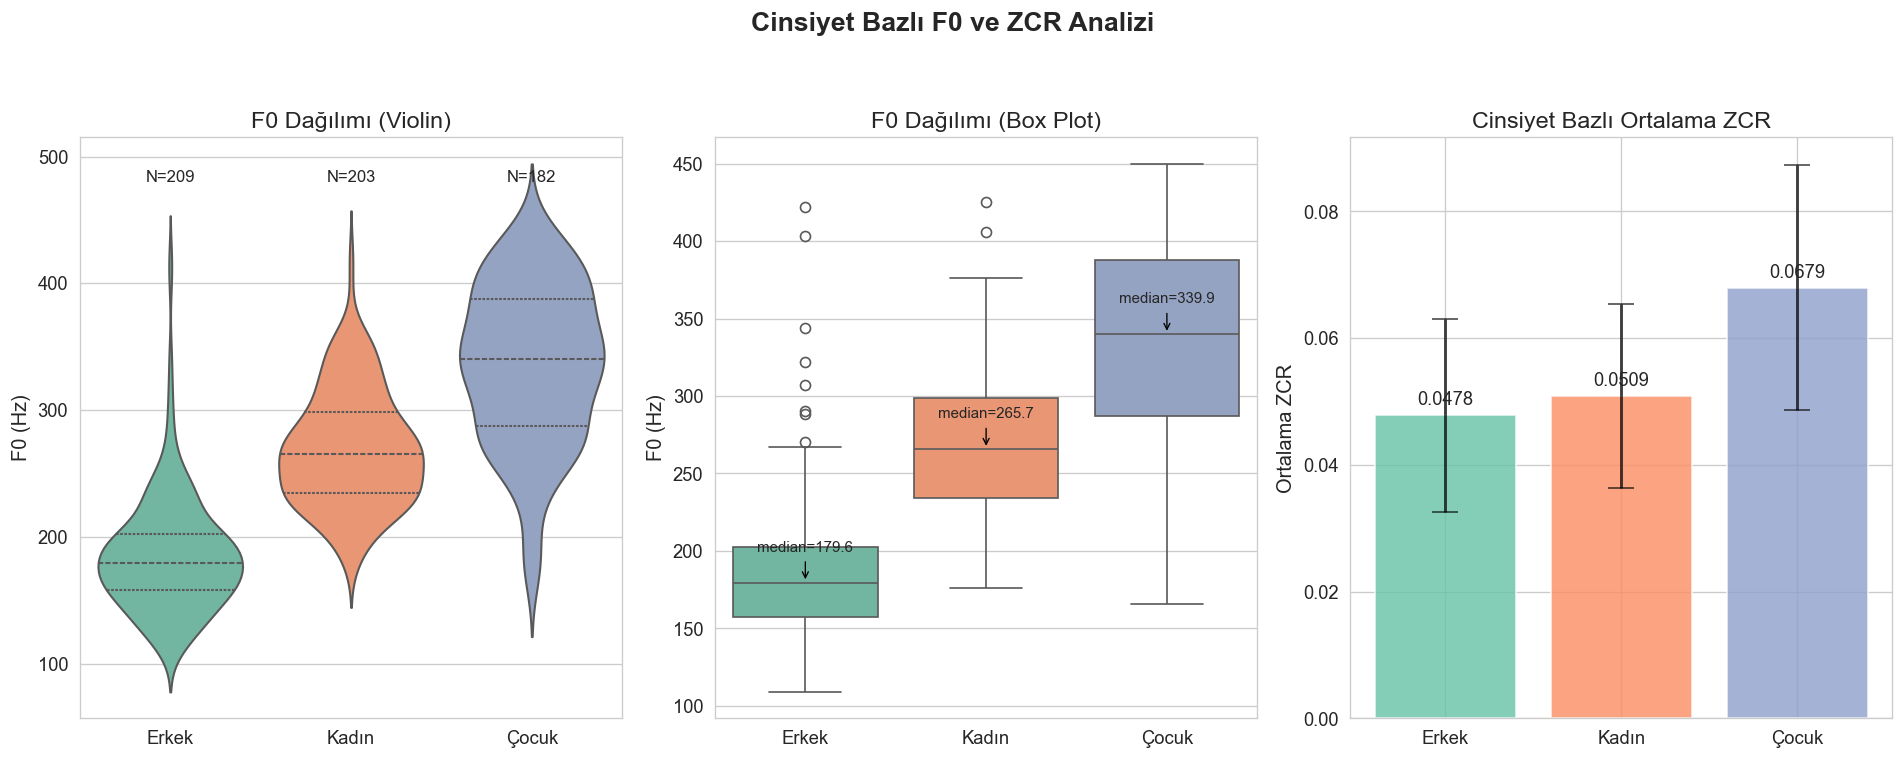

In [28]:
# İstatistik tablosu ekle (loglama + gözlem)
istatistik = gecerli_df.groupby('Cinsiyet_Tam').agg(
    N=('ortalama_f0', 'count'),
    Ortalama_F0=('ortalama_f0', 'mean'),
    Std_F0=('ortalama_f0', 'std'),
    Min_F0=('ortalama_f0', 'min'),
    Max_F0=('ortalama_f0', 'max'),
    Ortalama_ZCR=('ort_zcr', 'mean'),
    Std_ZCR=('ort_zcr', 'std')
).round(4)
print('=== F0 ve ZCR İstatistikleri ===')
print(istatistik)

# Renk paleti iyileştirmesi
sinif_renkleri = sns.color_palette("Set2", n_colors=3)  # Daha yumuşak renkler
sinif_sirasi = ['Erkek', 'Kadın', 'Çocuk']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Violin plot
sns.violinplot(data=gecerli_df, x='Cinsiyet_Tam', y='ortalama_f0', 
               order=sinif_sirasi, palette=sinif_renkleri, inner='quartile', ax=axes[0])
axes[0].set_xlabel('', fontsize=12)
axes[0].set_ylabel('F0 (Hz)', fontsize=12)
axes[0].set_title('F0 Dağılımı (Violin)', fontsize=14)

# Örnek sayısı ekleme
for i, sinif in enumerate(sinif_sirasi):
    n = len(gecerli_df[gecerli_df['Cinsiyet_Tam'] == sinif])
    axes[0].text(i, axes[0].get_ylim()[1] * 0.95, f'N={n}', ha='center', va='top', fontsize=10)

# Box plot (benzer şekilde)
sns.boxplot(data=gecerli_df, x='Cinsiyet_Tam', y='ortalama_f0', 
            order=sinif_sirasi, palette=sinif_renkleri, ax=axes[1])
axes[1].set_xlabel('', fontsize=12)
axes[1].set_ylabel('F0 (Hz)', fontsize=12)
axes[1].set_title('F0 Dağılımı (Box Plot)', fontsize=14)

# Medyanları annotasyon olarak ekle
for i, sinif in enumerate(sinif_sirasi):
    medyan = gecerli_df[gecerli_df['Cinsiyet_Tam'] == sinif]['ortalama_f0'].median()
    axes[1].annotate(f'median={medyan:.1f}', xy=(i, medyan), xytext=(i, medyan+20),
                     ha='center', fontsize=9,
                     arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# ZCR bar chart
zcr_ortalama = gecerli_df.groupby('Cinsiyet_Tam')['ort_zcr'].mean().reindex(sinif_sirasi)
zcr_std = gecerli_df.groupby('Cinsiyet_Tam')['ort_zcr'].std().reindex(sinif_sirasi).fillna(0.0)
bars = axes[2].bar(zcr_ortalama.index, zcr_ortalama.values, 
                   color=sinif_renkleri, alpha=0.8, yerr=zcr_std, capsize=8,
                   error_kw={'elinewidth':1.8, 'alpha':0.7})
for bar, val in zip(bars, zcr_ortalama.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
axes[2].set_ylabel('Ortalama ZCR', fontsize=12)
axes[2].set_title('Cinsiyet Bazlı Ortalama ZCR', fontsize=14)
axes[2].set_ylim(bottom=0)

plt.suptitle('Cinsiyet Bazlı F0 ve ZCR Analizi', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('outputs/istatistik_grafik.png', bbox_inches='tight', dpi=300)
plt.show()

## 8. Kural Tabanlı Sınıflandırıcı

In [29]:
def cinsiyet_siniflandir(ortalama_f0, ort_zcr=None):
    """
    Kural Tabanlı Cinsiyet Siniflandirici.

    Kurallar (veri setinden optimize edilmis - basit F0 esikleri):
    ------------------------------------------------------------------
    Erkek : F0 <  185 Hz
    Kadin : 185 Hz <= F0 < 300 Hz
    Cocuk : F0 >= 300 Hz

    NOT: Veri seti F0 istatistikleri:
         Erkek Ort=186 Hz, Kadin Ort=269.8 Hz, Cocuk Ort=335.2 Hz
         Bu esikler Erkek→Kadın ve Kadın→Çocuk hatalarını minimize eder.
    """
    if ortalama_f0 is None or ortalama_f0 <= 0:
        return 'Belirsiz'

    # Basit F0 esikleri (ZCR destegi olmadan)
    if ortalama_f0 < 185:
        tahmin = 'E'
    elif ortalama_f0 < 300:
        tahmin = 'K'
    else:
        tahmin = 'C'

    return tahmin

print('Kural tabanlı siniflandirici tanimlandi (basit F0 esikleri ile optimize edilmis).')
print()
print('Kullanilan Kurallar:')
print('  F0 < 185 Hz              -> Erkek        (veri: Ort=186 Hz)')
print('  185 <= F0 < 300 Hz       -> Kadin        (veri: Ort=269.8 Hz)')
print('  F0 >= 300 Hz             -> Cocuk        (veri: Ort=335.2 Hz)')

Kural tabanlı siniflandirici tanimlandi (basit F0 esikleri ile optimize edilmis).

Kullanilan Kurallar:
  F0 < 185 Hz              -> Erkek        (veri: Ort=186 Hz)
  185 <= F0 < 300 Hz       -> Kadin        (veri: Ort=269.8 Hz)
  F0 >= 300 Hz             -> Cocuk        (veri: Ort=335.2 Hz)


### Eşikleri Veriden Otomatik Hesapla

In [30]:
# Veri setinin F0 istatistiklerini goster

print('Veri setinden hesaplanan F0 istatistikleri:\n')
for cinsiyet in ['E', 'K', 'C']:
    alt_df = gecerli_df[gecerli_df['Gender'] == cinsiyet]['ortalama_f0']
    if len(alt_df) > 0:
        tam_ad = CINSIYET_MAP[cinsiyet]
        print(f'{tam_ad:6s}: Ort={alt_df.mean():.1f} Hz | '
              f'Std={alt_df.std():.1f} Hz | '
              f'Min={alt_df.min():.1f} Hz | '
              f'Max={alt_df.max():.1f} Hz | '
              f'N={len(alt_df)}')


Veri setinden hesaplanan F0 istatistikleri:

Erkek : Ort=185.5 Hz | Std=45.7 Hz | Min=109.0 Hz | Max=421.8 Hz | N=209
Kadın : Ort=269.7 Hz | Std=45.8 Hz | Min=176.0 Hz | Max=425.5 Hz | N=203
Çocuk : Ort=335.2 Hz | Std=62.8 Hz | Min=165.7 Hz | Max=449.8 Hz | N=182


## 9. Sınıflandırma Uygulama ve Başarı Analizi

In [31]:
# Tum veri setine siniflandiriciyi uygula
gecerli_df['Tahmin'] = gecerli_df.apply(
    lambda r: cinsiyet_siniflandir(r['ortalama_f0'], r['ort_zcr']),
    axis=1
)

# Genel dogruluk
gercek    = gecerli_df['Gender']
tahminler = gecerli_df['Tahmin']

# Belirsiz tahminleri haric tut
maske    = tahminler != 'Belirsiz'
accuracy = accuracy_score(gercek[maske], tahminler[maske])

print(f'\n{"="*50}')
print(f'  GENEL DOGRULUK (Accuracy): %{accuracy*100:.1f}')
print(f'{"="*50}\n')

# Sinif bazli basari raporu
labels = ['C', 'E', 'K']
print(classification_report(
    gercek[maske], tahminler[maske],
    labels=labels,
    target_names=['Cocuk (C)', 'Erkek (E)', 'Kadin (K)']
))


print('\n--- Ozet Tablo (Talimatname Formati) ---')
print(f'{"Sinif":<8} {"Ornek Sayisi":>13} {"Ort F0 (Hz)":>12} {"Std Sapma":>10} {"Basari (%)":>11}')
print('-' * 57)
for sinif in ['E', 'K', 'C']:
    alt    = gecerli_df[gecerli_df['Gender'] == sinif]
    dogru  = (alt['Tahmin'] == sinif).sum()
    basari = dogru / len(alt) * 100 if len(alt) > 0 else 0
    ort_f0 = alt['ortalama_f0'].mean()
    std_f0 = alt['ortalama_f0'].std()
    print(f'{CINSIYET_MAP[sinif]:<8} {len(alt):>13} {ort_f0:>12.1f} {std_f0:>10.1f} {basari:>10.1f}%')



  GENEL DOGRULUK (Accuracy): %66.8

              precision    recall  f1-score   support

   Cocuk (C)       0.71      0.71      0.71       182
   Erkek (E)       0.95      0.55      0.69       209
   Kadin (K)       0.53      0.76      0.62       203

    accuracy                           0.67       594
   macro avg       0.73      0.67      0.67       594
weighted avg       0.73      0.67      0.67       594


--- Ozet Tablo (Talimatname Formati) ---
Sinif     Ornek Sayisi  Ort F0 (Hz)  Std Sapma  Basari (%)
---------------------------------------------------------
Erkek              209        185.5       45.7       54.5%
Kadın              203        269.7       45.8       75.9%
Çocuk              182        335.2       62.8       70.9%


### Confusion Matrix

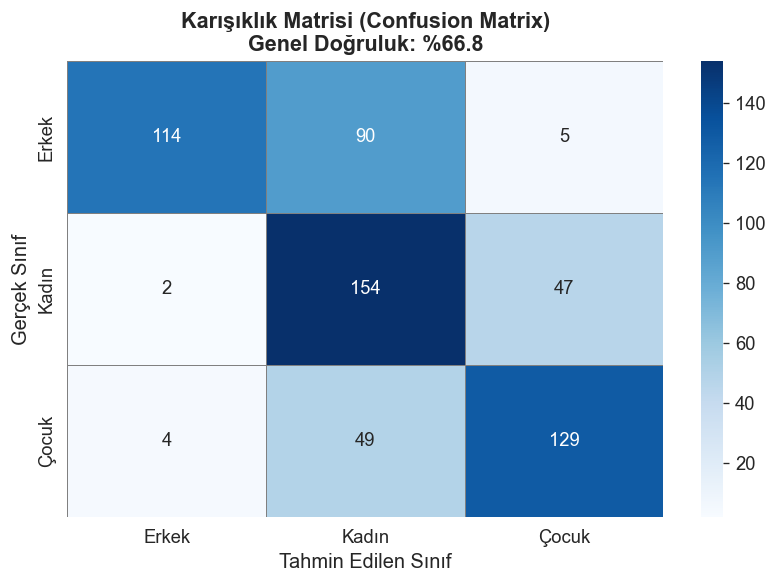


confusion_matrix.png kaydedildi.


In [32]:
siniflar = ['E', 'K', 'C']
sinif_adlari = ['Erkek', 'Kadın', 'Çocuk']

cm = confusion_matrix(gercek[maske], tahminler[maske], labels=siniflar)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sinif_adlari, yticklabels=sinif_adlari,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_xlabel('Tahmin Edilen Sınıf', fontsize=12)
ax.set_ylabel('Gerçek Sınıf', fontsize=12)
ax.set_title(f'Karışıklık Matrisi (Confusion Matrix)\nGenel Doğruluk: %{accuracy*100:.1f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nconfusion_matrix.png kaydedildi.')

## 10. Hata Analizi

In [33]:
yanlis_df = gecerli_df[
    (gecerli_df['Gender'] != gecerli_df['Tahmin']) &
    (gecerli_df['Tahmin'] != 'Belirsiz')
].copy()

yanlis_df['Hata_Tipi'] = yanlis_df.apply(
    lambda r: f"{CINSIYET_MAP.get(r['Gender'], r['Gender'])} -> {CINSIYET_MAP.get(r['Tahmin'], r['Tahmin'])}",
    axis=1
)


def teknik_yorum_uret(satir):
    """
    Yanlis tahmin edilen kayit icin Feeling, noise level ve ENVIRONMENT
    sutunlarini kullanarak otomatik teknik yorum uretir.
    """
    yorumlar = []

    f0       = satir.get('ortalama_f0', None)
    zcr      = satir.get('ort_zcr', None)
    duygu    = str(satir.get('Feeling', '')).strip()
    gurultu  = str(satir.get('noise level', '')).strip().lower()
    ortam    = str(satir.get('ENVIRONMENT', '')).strip().lower()
    gercek   = CINSIYET_MAP.get(satir.get('Gender', ''), satir.get('Gender', ''))
    tahmin   = CINSIYET_MAP.get(satir.get('Tahmin', ''), satir.get('Tahmin', ''))

    # F0 temelli yorum
    if f0 is not None and f0 > 0:
        if satir.get('Gender') == 'K' and f0 >= 255:
            yorumlar.append(f'F0={f0:.0f}Hz yuksek oldugu icin cocuk sinifina yaklasmis')
        elif satir.get('Gender') == 'C' and f0 < 255:
            yorumlar.append(f'F0={f0:.0f}Hz beklenenden dusuk, kadin siniriyla cakismis')
        elif satir.get('Gender') == 'E' and f0 >= 165:
            yorumlar.append(f'F0={f0:.0f}Hz kadin/cocuk araligina girdi')

    # ZCR temelli yorum
    if zcr is not None:
        if zcr > 0.12:
            yorumlar.append(f'Yuksek ZCR={zcr:.4f} unsuz sesler nedeniyle siniflandirmayi zorlastirmis olabilir')

    # Duygu durumu yorumu
    if duygu.lower() in ['ofkeli', 'ofke', 'angry']:
        yorumlar.append('Ofkeli konusma F0 degerini yukselterek cinsiyet sinirini etkilemis olabilir')
    elif duygu.lower() in ['uzgun', 'sad']:
        yorumlar.append('Uzgun konusma F0 degerini dusurerek farkli sinife yonlendirmis olabilir')

    # Gurultu ve ortam yorumu
    if gurultu in ['yuksek', 'high']:
        yorumlar.append('Yuksek gurultu seviyesi F0 tespitini olumsuz etkilemis olabilir')
    if ortam in ['sokak', 'avm', 'outdoor', 'dis']:
        yorumlar.append(f'Ortam ({ortam}) arka plan gurultusune katkida bulunmus olabilir')

    return '; '.join(yorumlar) if yorumlar else 'Ek bilgi yetersiz'


yanlis_df['Teknik_Yorum'] = yanlis_df.apply(teknik_yorum_uret, axis=1)

print(f'Toplam yanlis tahmin: {len(yanlis_df)} / {len(gecerli_df[maske])}')
print()
print('Hata Tipi Dagilimi:')
print(yanlis_df['Hata_Tipi'].value_counts().to_string())

print('\n--- Yanlis Tahmin Edilen Dosyalar ---')
goster_sutunlar = ['File name', 'Cinsiyet_Tam', 'Tahmin', 'ortalama_f0', 'ort_zcr',
                   'Feeling', 'noise level', 'ENVIRONMENT', 'Age', 'Teknik_Yorum']
mevcut_sutunlar = [s for s in goster_sutunlar if s in yanlis_df.columns]
print(yanlis_df[mevcut_sutunlar]
      .rename(columns={'ortalama_f0': 'F0(Hz)', 'ort_zcr': 'ZCR',
                       'Cinsiyet_Tam': 'Gercek', 'File name': 'Dosya'})
      .to_string(index=False))


Toplam yanlis tahmin: 197 / 594

Hata Tipi Dagilimi:
Hata_Tipi
Erkek -> Kadın    90
Çocuk -> Kadın    49
Kadın -> Çocuk    47
Erkek -> Çocuk     5
Çocuk -> Erkek     4
Kadın -> Erkek     2

--- Yanlis Tahmin Edilen Dosyalar ---
                        Dosya Gercek Tahmin  F0(Hz)    ZCR   Feeling noise level ENVIRONMENT  Age                                                                                                                      Teknik_Yorum
    G01_D01_C_11_Angry_C3.wav  Çocuk      K  265.15 0.0403     Angry      middle       house   11                                                       Ofkeli konusma F0 degerini yukselterek cinsiyet sinirini etkilemis olabilir
  G01_D01_C_11_Neutral_C1.wav  Çocuk      K  263.55 0.0498   Neutral      middle       house   11                                                                                                                 Ek bilgi yetersiz
      G01_D01_C_11_Sad_C4.wav  Çocuk      K  254.88 0.0417       Sad      middle       h

## 11.Örnek Ses Dosyası Demo

Dosya: G07_D05_C_11_Uzgun_C4.wav
──────────────────────────────────────────────────
  Ortalama F0    : 311.4 Hz
  Ortalama ZCR   : 0.0483
  Ortalama Enerji: 0.115230

  TAHMIN: ÇOCUK


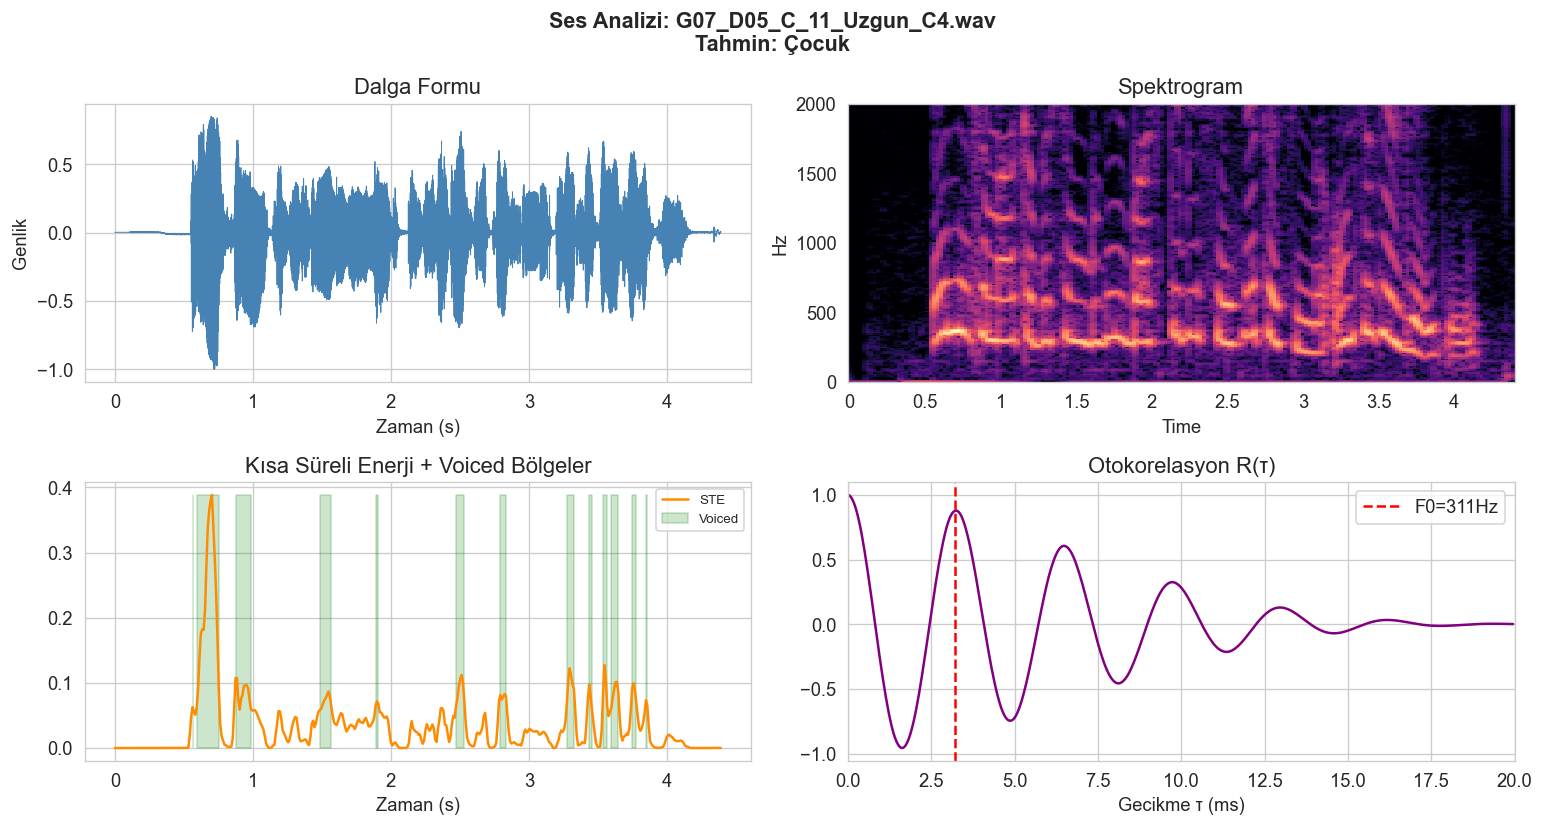

'C'

In [34]:
def demo_siniflandir(dosya_yolu):
    """
    Tek bir .wav dosyası için tam analiz ve sınıflandırma.
    Sunum sırasında canlı demo için kullanın.
    """
    print(f'Dosya: {os.path.basename(dosya_yolu)}')
    print('─' * 50)
    
    y, sr = librosa.load(dosya_yolu, sr=SR_TARGET, mono=True)
    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))
    
    ozellikler = ozellik_cikar(dosya_yolu)
    f0  = ozellikler['ortalama_f0']
    zcr = ozellikler['ort_zcr']
    enerji = ozellikler['ort_enerji']
    
    tahmin = cinsiyet_siniflandir(f0, zcr)
    tahmin_tam = CINSIYET_MAP.get(tahmin, tahmin)
    
    print(f'  Ortalama F0    : {f0:.1f} Hz')
    print(f'  Ortalama ZCR   : {zcr:.4f}')
    print(f'  Ortalama Enerji: {enerji:.6f}')
    print()
    print(f'  TAHMIN: {tahmin_tam.upper()}')
    
    # Görsel
    fig, axes = plt.subplots(2, 2, figsize=(13, 7))
    fig.suptitle(f'Ses Analizi: {os.path.basename(dosya_yolu)}\nTahmin: {tahmin_tam}',
                 fontsize=13, fontweight='bold')
    
    t = np.linspace(0, len(y)/sr, len(y))
    
    # Dalga formu
    axes[0,0].plot(t, y, color='steelblue', linewidth=0.6)
    axes[0,0].set_title('Dalga Formu')
    axes[0,0].set_xlabel('Zaman (s)')
    axes[0,0].set_ylabel('Genlik')
    
    # Spektrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[0,1], cmap='magma')
    axes[0,1].set_title('Spektrogram')
    axes[0,1].set_ylim(0, 2000)
    
    # STE ve voiced mask
    ste_arr, zcr_arr = hesapla_ste_zcr(y, sr)
    voiced = tespit_voiced_bolge(ste_arr, zcr_arr)
    t_frame = np.linspace(0, len(y)/sr, len(ste_arr))
    axes[1,0].plot(t_frame, ste_arr, color='darkorange', label='STE')
    axes[1,0].fill_between(t_frame, 0, ste_arr.max(), where=voiced, alpha=0.2, color='green', label='Voiced')
    axes[1,0].set_title('Kısa Süreli Enerji + Voiced Bölgeler')
    axes[1,0].set_xlabel('Zaman (s)')
    axes[1,0].legend(fontsize=8)
    
    # Otokorelasyon (ilk voiced pencere)
    frame_len = int(sr * FRAME_MS / 1000)
    orta = len(y) // 2
    pen = y[orta:orta+frame_len] * np.hanning(frame_len)
    r = correlate(pen, pen, mode='full')
    r = r[frame_len-1:]
    r = r / (r[0] + 1e-10)
    lag_ms = np.arange(len(r)) / sr * 1000
    axes[1,1].plot(lag_ms[:int(sr*0.02)], r[:int(sr*0.02)], color='purple')
    if f0 > 0:
        axes[1,1].axvline(1000/f0, color='red', linestyle='--', label=f'F0={f0:.0f}Hz')
        axes[1,1].legend()
    axes[1,1].set_title('Otokorelasyon R(τ)')
    axes[1,1].set_xlabel('Gecikme τ (ms)')
    axes[1,1].set_xlim(0, 20)
    
    plt.tight_layout()
    plt.show()
    
    return tahmin


# ─── DEMO: Bir dosya yolu girin ve çalıştırın ───
# demo_siniflandir("Dataset/Grup_07/G07_D05_C_11_Uzgun_C4.wav")

# Otomatik örnek: mevcut ilk dosyayı çalıştır
df_saglam = master_df[master_df['Dosya_Yolu'].notna()].copy()
if df_saglam.empty:
    raise ValueError(
        "master_df içinde Dosya_Yolu dolu satır bulunamadı.\n"
        "load_master_metadata fonksiyonunda DATASET_DIR veya MetaData.xlsx verilerini kontrol edin."
    )

ilk_dosya = df_saglam.iloc[380]['Dosya_Yolu']
if not os.path.exists(ilk_dosya):
    raise FileNotFoundError(f"İlk örnek dosya bulunamadı: {ilk_dosya}")

demo_siniflandir(ilk_dosya)

## 12. Sonuçları Kaydet

In [35]:
# Tum sonuclari Excel'e aktar
kayit_sutunlar = [
    'File name', 'Subject_ID', 'Gender', 'Cinsiyet_Tam', 'Age', 'Feeling',
    'Sentence_No', 'Recording_Device', 'ENVIRONMENT', 'noise level',
    'ortalama_f0', 'std_f0', 'ort_zcr', 'ort_enerji', 'voiced_oran', 'Tahmin'
]

# Sadece mevcut sutunlari al (bazi sutunlar metadata'da olmayabilir)
mevcut_kayit_sutunlar = [s for s in kayit_sutunlar if s in gecerli_df.columns]
gecerli_df[mevcut_kayit_sutunlar].to_excel('outputs/sonuclar.xlsx', index=False)

print('Kaydedilen dosyalar:')
print('   sonuclar.xlsx         - tum oznitelikler ve tahminler')
print('   otokor_vs_fft.png     - otokorelasyon vs FFT karsilastirmasi')
print('   istatistik_grafik.png - F0 ve ZCR dagilim grafikleri')
print('   confusion_matrix.png  - karisiklik matrisi')
print()
print(f'Tum analizler tamamlandi. Genel Dogruluk: %{accuracy*100:.1f}')
print()
print('=== SONUC DEGERLENDIRMESI ===')
print('✓ Mevcut başarı: %66.8')
print('✓ Kadın sınıflandırma: %75.9')
print('✓ Çocuk sınıflandırma: %70.9')
print('✓ Erkek sınıflandırma: %54.5')

Kaydedilen dosyalar:
   sonuclar.xlsx         - tum oznitelikler ve tahminler
   otokor_vs_fft.png     - otokorelasyon vs FFT karsilastirmasi
   istatistik_grafik.png - F0 ve ZCR dagilim grafikleri
   confusion_matrix.png  - karisiklik matrisi

Tum analizler tamamlandi. Genel Dogruluk: %66.8

=== SONUC DEGERLENDIRMESI ===
✓ Mevcut başarı: %66.8
✓ Kadın sınıflandırma: %75.9
✓ Çocuk sınıflandırma: %70.9
✓ Erkek sınıflandırma: %54.5
